<a href="https://colab.research.google.com/github/adityarizqiqa/PCVK_Ganjil2026/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()

Saving KTP1.jpeg to KTP1.jpeg


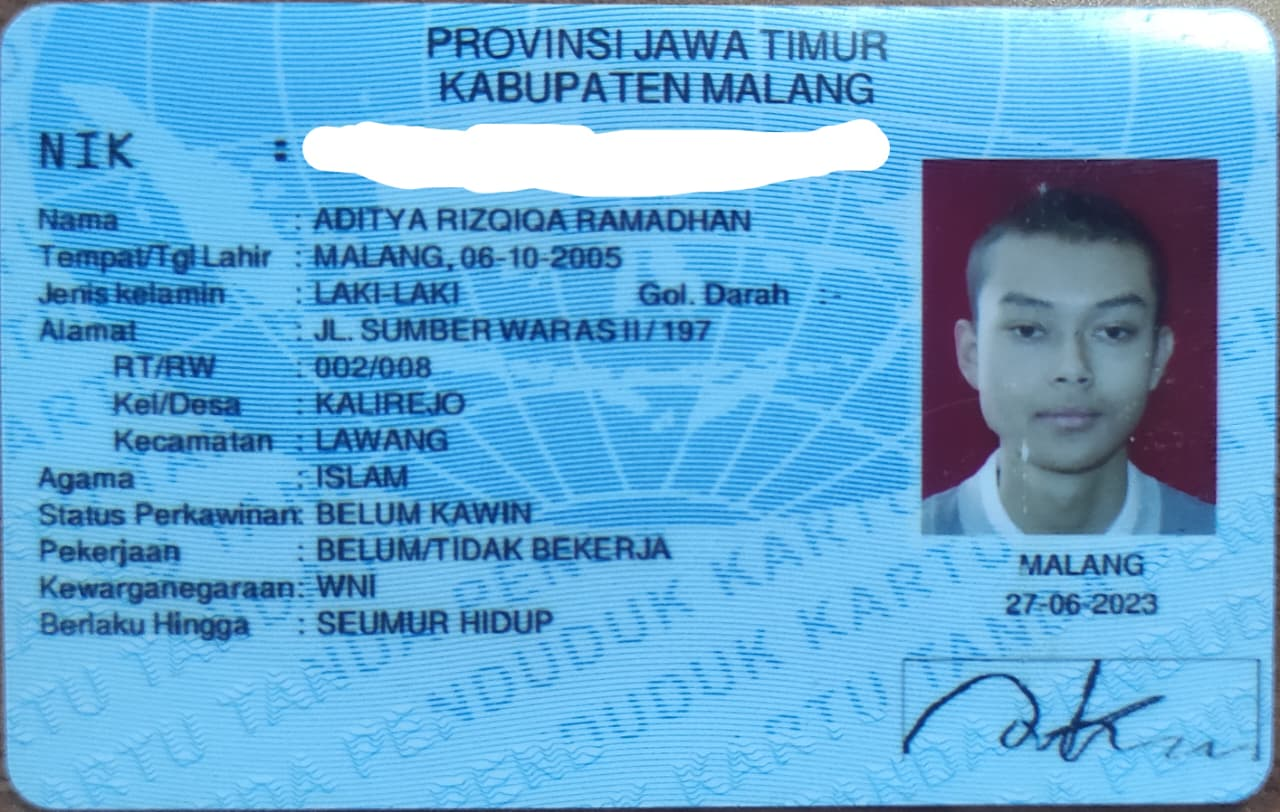

Resolusi gambar:  1280 x 812


In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt

img = cv.imread('KTP1.jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

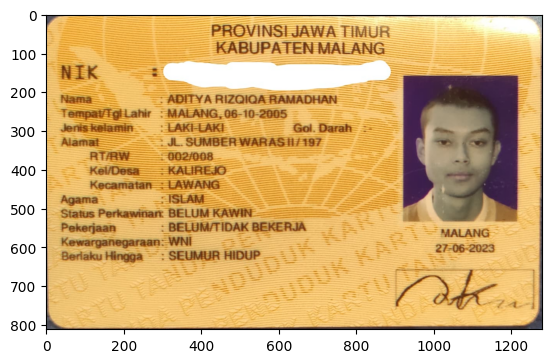

In [5]:
img = cv.imread('KTP1.jpeg')
plt.imshow(img)

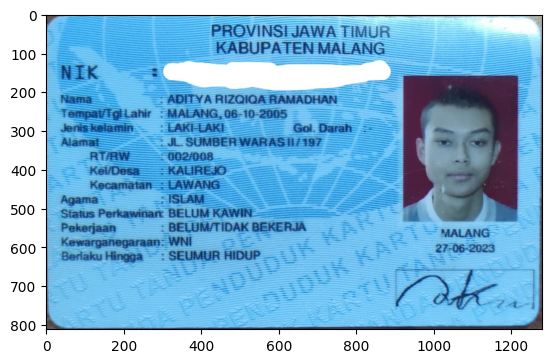

In [6]:
img = cv.imread('KTP1.jpeg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img2)

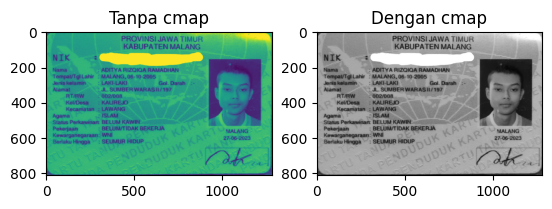

In [7]:
img_gray = cv.imread('KTP1.jpeg', cv.IMREAD_GRAYSCALE)

plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

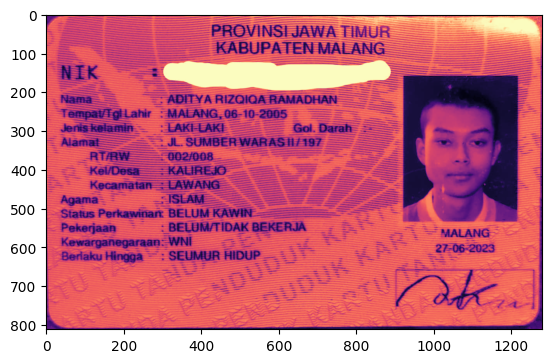

In [8]:
plt.imshow(img_gray, cmap='magma')

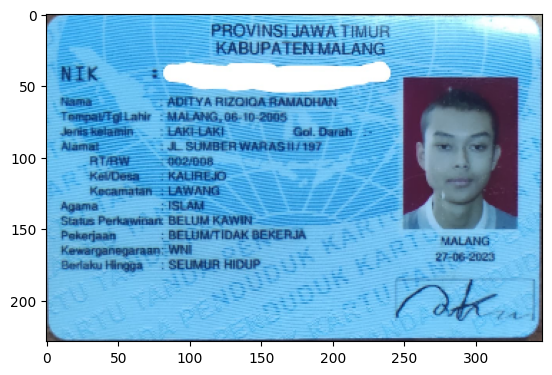

In [9]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

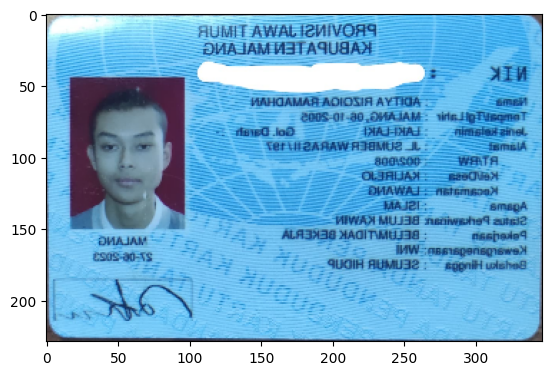

In [10]:
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

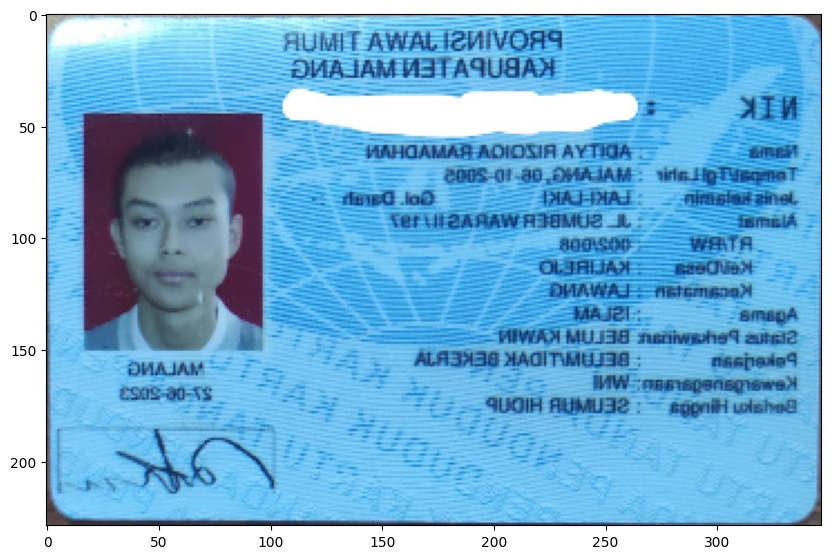

In [12]:
imgFlip=cv.flip(img_output, 1)

fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

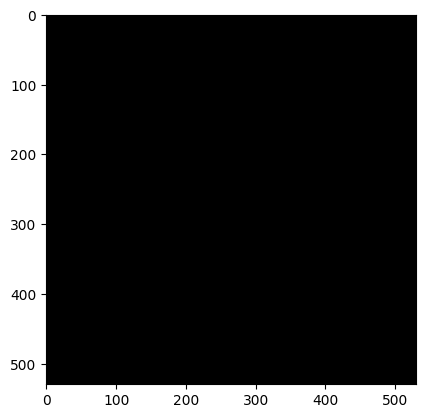

In [14]:
import numpy as np

black_img = np.zeros(shape=(530, 530, 3), dtype=np.int16)
plt.imshow(black_img)

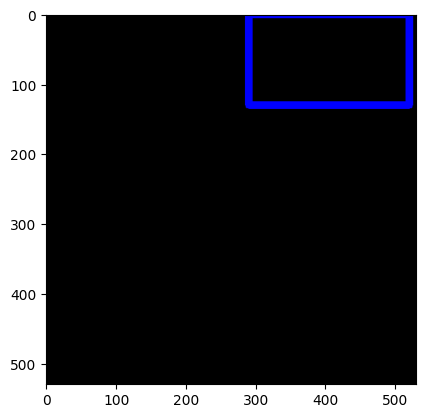

In [15]:
cv.rectangle(black_img, pt1=(290,0), pt2=(520,130), color=(0, 0, 255), thickness=10)
plt.imshow(black_img)

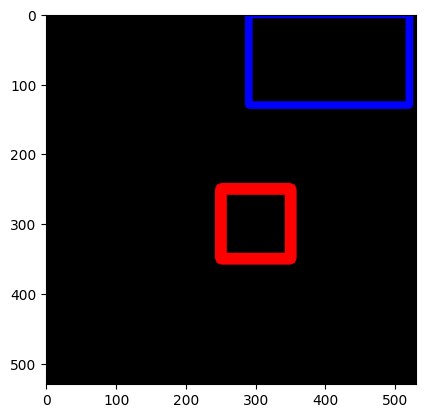

In [16]:
cv.rectangle(black_img, pt1=(250,250), pt2=(350,350), color=(255, 0, 0), thickness=15)
plt.imshow(black_img)

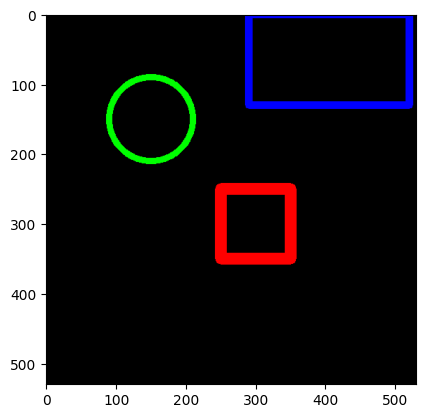

In [17]:
cv.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness = 8)
plt.imshow(black_img)

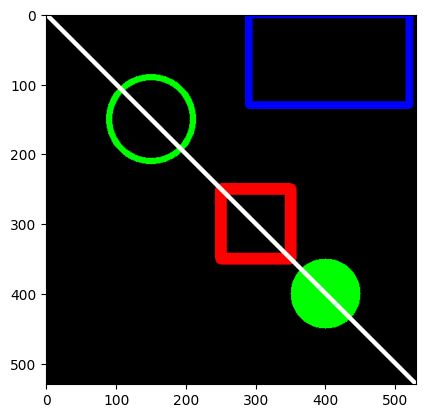

In [18]:
cv.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1)
cv.line(black_img, pt1=(0,0), pt2=(530,530), color=(255, 255, 255), thickness=5)
plt.imshow(black_img)

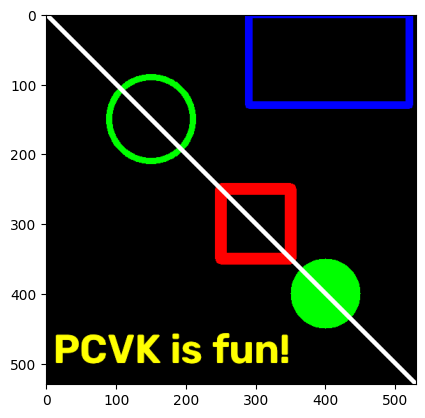

In [21]:
font = cv.FONT_HERSHEY_SIMPLEX
black_img = black_img.astype(np.uint8)
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2, color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

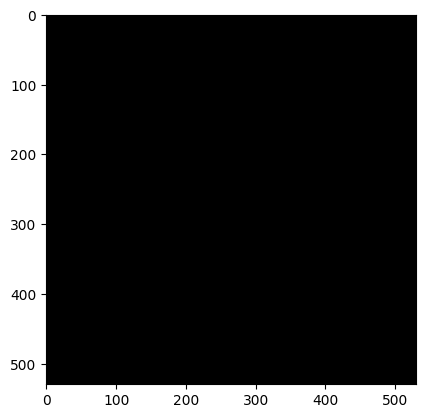

In [22]:
black_img2=np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

In [23]:
vertices = np.array([[150,350], [250,250], [450,350], [250,450]], dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [24]:
pts = vertices.reshape((-1,1,2))
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

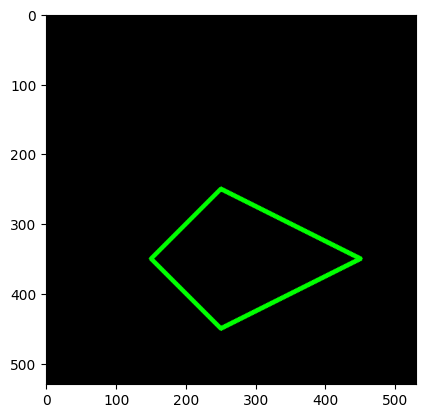

In [25]:
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

Nilai piksel cv2 (BGR) : [ 85  84 100]
Nilai piksel skimage (RGB): [100  84  85]


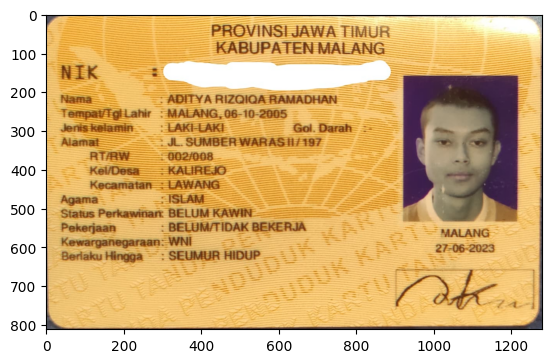

In [28]:
#PERTANYAAN PRAKTIKUM (1)
import cv2
import matplotlib.pyplot as plt
import skimage.io as io

img_cv2 = cv2.imread('KTP1.jpeg') # Format BGR
img_plt = io.imread('KTP1.jpeg')  # Format RGB

print("Nilai piksel cv2 (BGR) :", img_cv2[0, 0])
print("Nilai piksel skimage (RGB):", img_plt[0, 0])

plt.imshow(img_cv2)
#plt.imshow(img_plt)

Hasilnya berbeda karena perbedaan format pembacaan channel warna. OpenCV (cv2.imread) secara default membaca citra dalam urutan kanal BGR (Blue, Green, Red). Sedangkan Matplotlib (plt.imshow) menampilkan citra dengan asumsi format RGB (Red, Green, Blue).

int16 -> dtype: int16, min: 0, max: 0, nbytes: 20000 bytes
int32 -> dtype: int32, min: 0, max: 0, nbytes: 40000 bytes


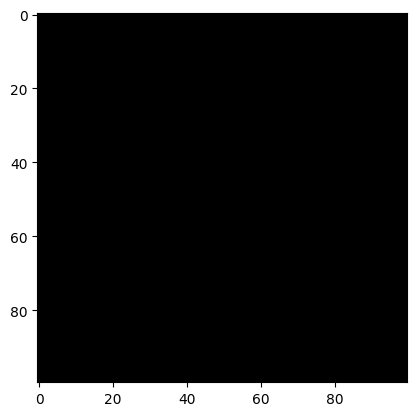

In [39]:
#PERTANYAAN PRAKTIKUM (2)

import numpy as np

kanvas_16 = np.zeros((100, 100), dtype=np.int16)
kanvas_32 = np.zeros((100, 100), dtype=np.int32)

print(f"int16 -> dtype: {kanvas_16.dtype}, min: {kanvas_16.min()}, max: {kanvas_16.max()}, nbytes: {kanvas_16.nbytes} bytes")
print(f"int32 -> dtype: {kanvas_32.dtype}, min: {kanvas_32.min()}, max: {kanvas_32.max()}, nbytes: {kanvas_32.nbytes} bytes")

black_img3=np.zeros((100, 100, 3), dtype=np.int16)
#black_img3=np.zeros((100, 100, 3), dtype=np.int32)
plt.imshow(black_img3)

Untuk tampilan keduanya sama-sama hitam pekat, tetapi pada ukuran berbeda karena kanvas int16 menggunakan 2 byte per piksel, sedangkan int32 menggunakan 4 byte per piksel.


#PERTANYAAN PRAKTIKUM (3)

Fungsi cv2.imshow() bawaan OpenCV dirancang untuk membuka jendela GUI eksternal pada sistem operasi lokal. Karena Google Colab berjalan di browser pada server cloud, ia tidak dapat merender jendela GUI lokal. Oleh karena itu, patch cv2_imshow disediakan untuk merender matriks citra menjadi format gambar (seperti PNG) agar bisa ditampilkan sebaris (inline) di antarmuka Colab.

Piksel skimage.io       : [100  84  85]
Piksel cv2 + cvtColor   : [100  84  85]


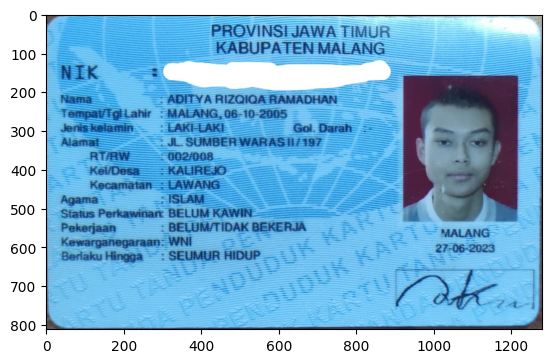

In [40]:
#PERTANYAAN PRAKTIKUM (4)

img_skimage = io.imread('KTP1.jpeg')
img_cv2 = cv2.imread('KTP1.jpeg')
img_converted = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

print("Piksel skimage.io       :", img_skimage[0, 0])
print("Piksel cv2 + cvtColor   :", img_converted[0, 0])

plt.imshow(img_converted)

Keduanya menampilkan warna yang sebenarnya jika sudah dikonversi. skimage.io.imread membaca RGB, sedangkan cv2.cvtColor mengonversi BGR hasil bacaan OpenCV menjadi RGB.

#PERTANYAAN PRAKTIKUM (5)

Nilai img.shape tidak akan berubah, mengubah parameter figsize pada Matplotlib hanya memanipulasi ukuran tampilan (area kanvas/plot di layar visual), sedangkan matriks data citra aslinya (dimensi array NumPy) tetap sama di dalam memori.

In [41]:
#TUGAS PRAKTIKUM - PENERAPAN

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [42]:
#TUGAS PRAKTIKUM - PENERAPAN

from google.colab import files
uploaded = files.upload()

Saving Lenna_(test_image).png to Lenna_(test_image).png


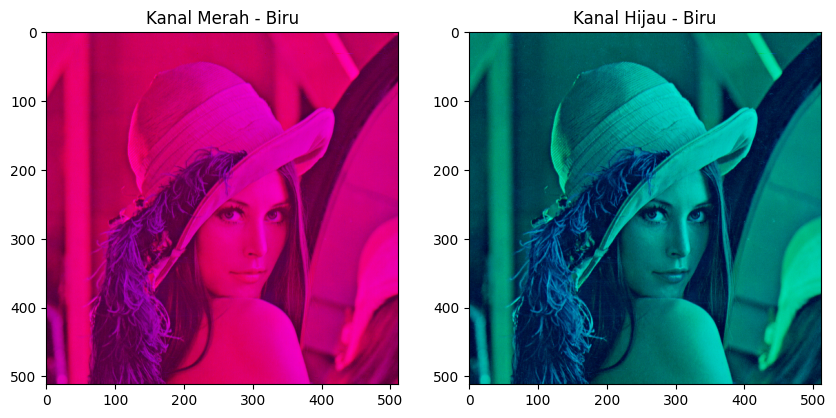

In [45]:
#TUGAS PRAKTIKUM - PENERAPAN

# 1. Kanal Merah-Biru dan Hijau-Biru ---
img = cv2.imread('Lenna_(test_image).png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Merah-Biru
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# Hijau-Biru
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_rb)
axs[0].set_title('Kanal Merah - Biru')
axs[1].imshow(img_gb)
axs[1].set_title('Kanal Hijau - Biru')
plt.show()

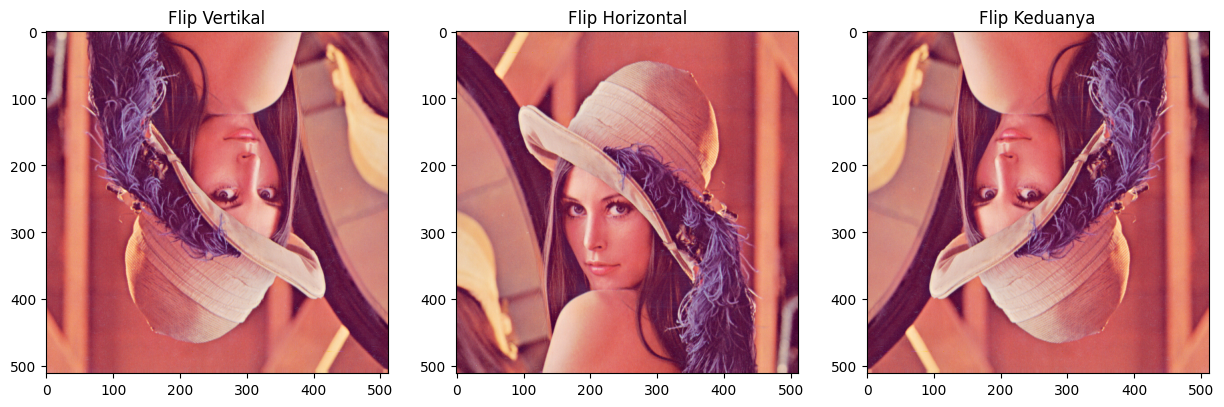

In [46]:
#TUGAS PRAKTIKUM - PENERAPAN

# 2. Pencerminan Citra
flip_v = cv2.flip(img_rgb, 0)
flip_h = cv2.flip(img_rgb, 1)
flip_both = cv2.flip(img_rgb, -1)

fig2, axs2 = plt.subplots(1, 3, figsize=(15, 5))
axs2[0].imshow(flip_v)
axs2[0].set_title('Flip Vertikal')
axs2[1].imshow(flip_h)
axs2[1].set_title('Flip Horizontal')
axs2[2].imshow(flip_both)
axs2[2].set_title('Flip Keduanya')
plt.show()

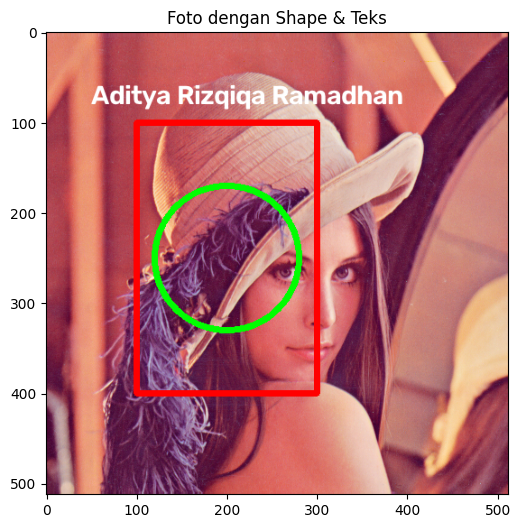

In [47]:
#TUGAS PRAKTIKUM - PENERAPAN

# 3. Menggambar Shape dan Teks Nama
img_draw = img_rgb.copy()

cv2.rectangle(img_draw, (100, 100), (300, 400), (255, 0, 0), 5)
cv2.circle(img_draw, (200, 250), 80, (0, 255, 0), 5)

# Menambahkan Teks Nama (Ukuran font adaptif)
cv2.putText(img_draw, 'Aditya Rizqiqa Ramadhan', (50, 80),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

plt.figure(figsize=(8, 6))
plt.imshow(img_draw)
plt.title('Foto dengan Shape & Teks')
plt.show()

In [59]:
#TUGAS PRAKTIKUM - ANALISA

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [63]:
#TUGAS PRAKTIKUM - ANALISA

from google.colab import files
uploaded = files.upload()

Saving KTM.jpeg to KTM.jpeg


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

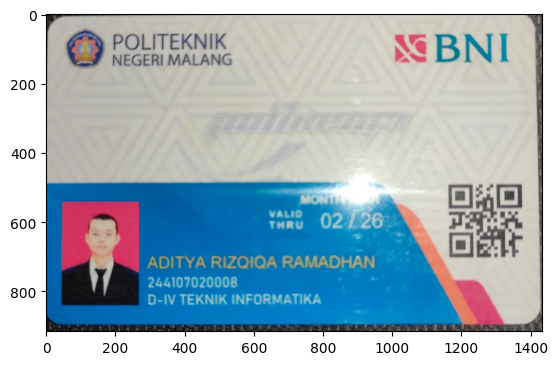

In [65]:
#TUGAS PRAKTIKUM - ANALISA

img = cv2.imread('KTM.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt

In [66]:
#TUGAS PRAKTIKUM - ANALISA

wajah = img_rgb[100:400, 100:300]
red_channel = wajah[:, :, 0]
red_pixels_high = np.sum(red_channel > 150)
total_pixels = wajah.shape[0] * wajah.shape[1]
persentase = (red_pixels_high / total_pixels) * 100
print(f"Persentase piksel merah > 150: {persentase:.2f}%")

Persentase piksel merah > 150: 92.91%


In [67]:
#TUGAS PRAKTIKUM - APLIKASI

import cv2
import numpy as np

In [68]:
from google.colab import files
uploaded = files.upload()

Saving BURUNG.jpg to BURUNG.jpg


In [76]:
from google.colab import files
uploaded = files.upload()

Saving ULAR.jpg to ULAR.jpg


In [78]:
def tambah_label_dokumentasi(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Hitung proporsi dinamis dari input
    h, w, _ = img_rgb.shape
    bar_height = h // 12

    # Bar label hitam di bagian paling bawah gambar
    cv2.rectangle(img_rgb, (0, h - bar_height), (w, h), (0, 0, 0), -1)

    # Hitung ukuran font adaptif berdasarkan tinggi bar
    font_scale = bar_height / 45.0
    thickness = max(1, int(font_scale * 1))

    # Posisi teks: X sedikit menjorok, Y di tengah bar
    text = "Dokumentasi PCVK - 2026"
    text_y = h - (bar_height // 3)
    cv2.putText(img_rgb, text, (15, text_y),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)

    return img_rgb

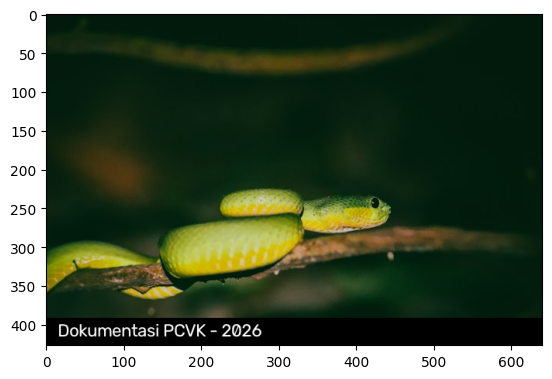

In [82]:
plt.imshow(tambah_label_dokumentasi('ULAR.jpg'))

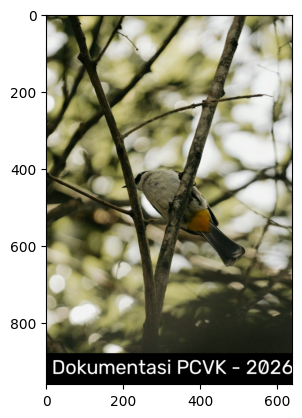

In [83]:
plt.imshow(tambah_label_dokumentasi('BURUNG.jpg'))

In [87]:
def buat_thumbnail_square(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img_rgb.shape
    max_dim = max(h, w)

    # kanvas NumPy persegi warna putih
    canvas = np.full((max_dim, max_dim, 3), 255, dtype=np.uint8)

    # Hitung offset untuk menempatkan gambar tepat di tengah
    y_offset = (max_dim - h) // 2
    x_offset = (max_dim - w) // 2

    # Menempatkan gambar menggunakan slicing NumPy
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = img_rgb

    # Teks nama toko
    font_scale = max_dim / 800.0
    thickness = max(1, int(font_scale * 3))
    cv2.putText(canvas, "Toko Aditya", (20, max_dim - 20),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (100, 100, 100), thickness)

    return canvas

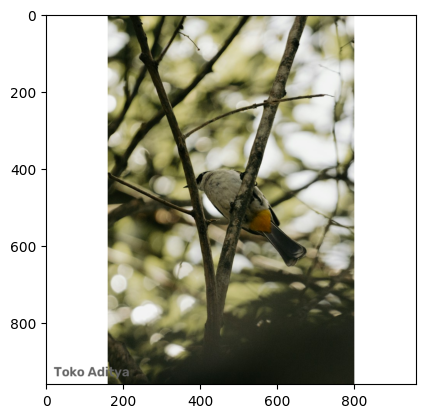

In [86]:
plt.imshow(buat_thumbnail_square('BURUNG.jpg'))

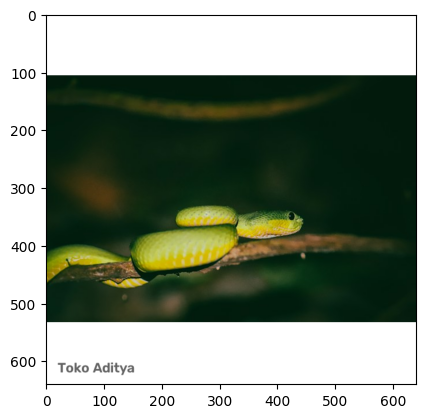

In [88]:
plt.imshow(buat_thumbnail_square('ULAR.jpg'))